# Week 3 — Open-Source AI Models

This notebook explores **three powerful open-source AI models** from Hugging Face, all run on a **free Colab GPU (T4)**.

| Section | Model | Task |
|---------|-------|------|
| 1 | SDXL-Turbo | Ultra-fast image generation (4 steps) |
| 2 | Stable Diffusion XL | High-quality image generation (base + refiner pipeline) |
| 3 | SpeechT5 TTS | Text-to-Speech — convert text into spoken audio |

#
> **Important:** Each section requires a fresh GPU memory. We restart the kernel between sections so the GPU doesn't run out of VRAM.

---
## Section 1: SDXL-Turbo — Ultra-Fast Image Generation

**What is SDXL-Turbo?**
SDXL-Turbo is a speed-optimized version of Stable Diffusion XL made by Stability AI. Standard image models need 30–50 steps to create an image. SDXL-Turbo uses a technique called **Adversarial Diffusion Distillation (ADD)** to produce great results in just **1–4 steps**, making it ~10x faster.

In [ ]:
import os
os.kill(os.getpid(), 9)

### Install Required Libraries

- **`transformers`** — Hugging Face library to load any AI model in 1 line
- **`diffusers`** — Hugging Face library specifically for image generation models (Stable Diffusion etc.)
- **`huggingface-hub`** — Handles logging in and downloading models from HuggingFace

In [1]:
# The -U flag means 'upgrade to the latest version if already installed'.
!pip install -U transformers diffusers gradio huggingface-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 57.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 2.6.1
    Uninstalling gradio_client-2.6.1:
      Successfully uninstalled gradio_client-2.6.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: gradio
    Found existing installation: gradio 6.26.0
    Uninstalling gradio-6.26.0:
      Successfully uni

In [2]:
# Import the libraries and print their versions to confirm they installed correctly.
import transformers
import diffusers
import huggingface_hub

print("transformers:", transformers.__version__)
print("diffusers:", diffusers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

transformers: 5.18.0
diffusers: 0.40.0
huggingface_hub: 1.33.0


In [3]:
from huggingface_hub import login
from google.colab import userdata

# Read the Hugging Face token from userdata
hf_token = userdata.get("HF_TOKEN")

# Log in to HuggingFace
login(hf_token, add_to_git_credential=True)

In [5]:
import torch
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Generate an Image with SDXL-Turbo

**How it works step by step:**
1. We load `sdxl-turbo` using `AutoPipelineForText2Image` — a smart class that automatically picks the right pipeline for this model
2. We move the model to the GPU (`cuda`) so it runs fast
3. We write a text prompt describing the image we want
4. We call the pipeline with only **4 inference steps** (standard SDXL needs 30+!) and `guidance_scale=0.0` (a special setting that makes Turbo work)
5. The output is a PIL Image object that we display inline

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


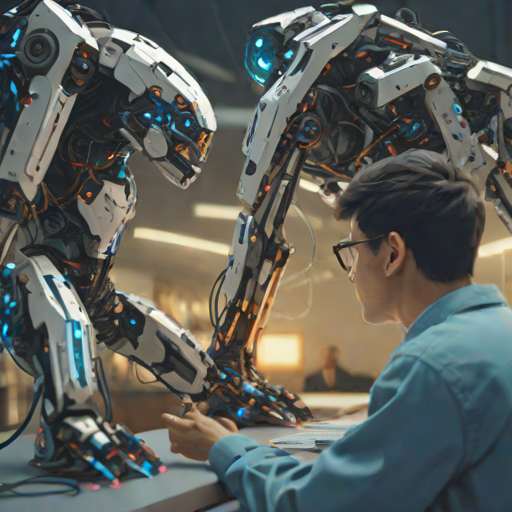

In [6]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image   # Smart pipeline loader for image generation

# Load SDXL-Turbo from Hugging Face Hub
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,    # torch_dtype=torch.float16 → use 16-bit floats to save GPU memory (half precision)
    variant="fp16"    # variant='fp16' → download the fp16 version of the model weights
).to(device)    # Move the entire model to the GPU for fast inference

# The text description of the image we want to create
prompt = "A student exploring the world of Artificial Intelligence, machine learning, robotics, and data science in a cinematic digital art style"

# Generate the image
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]

# Display the generated image inline in the notebook
display(image)

In [7]:
# This clears ALL variables and GPU memory from Section 1.
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [2]:
import torch
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## Section 2A: Stable Diffusion XL Base — High-Quality Image Generation

**What is Stable Diffusion XL (SDXL)?**
SDXL is the full, high-quality version of Stable Diffusion. Unlike SDXL-Turbo which sacrifices some quality for speed, SDXL Base uses **30 full denoising steps** to produce stunning, detailed images.

**Difference from Turbo:**
| Feature | SDXL-Turbo | SDXL Base |
|---------|-----------|----------|
| Steps | 4 | 30 |
| Speed | ~1 second | ~10–20 seconds |
| Quality | Good | Excellent |
| guidance_scale | 0.0 | 7.5 (default) |

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


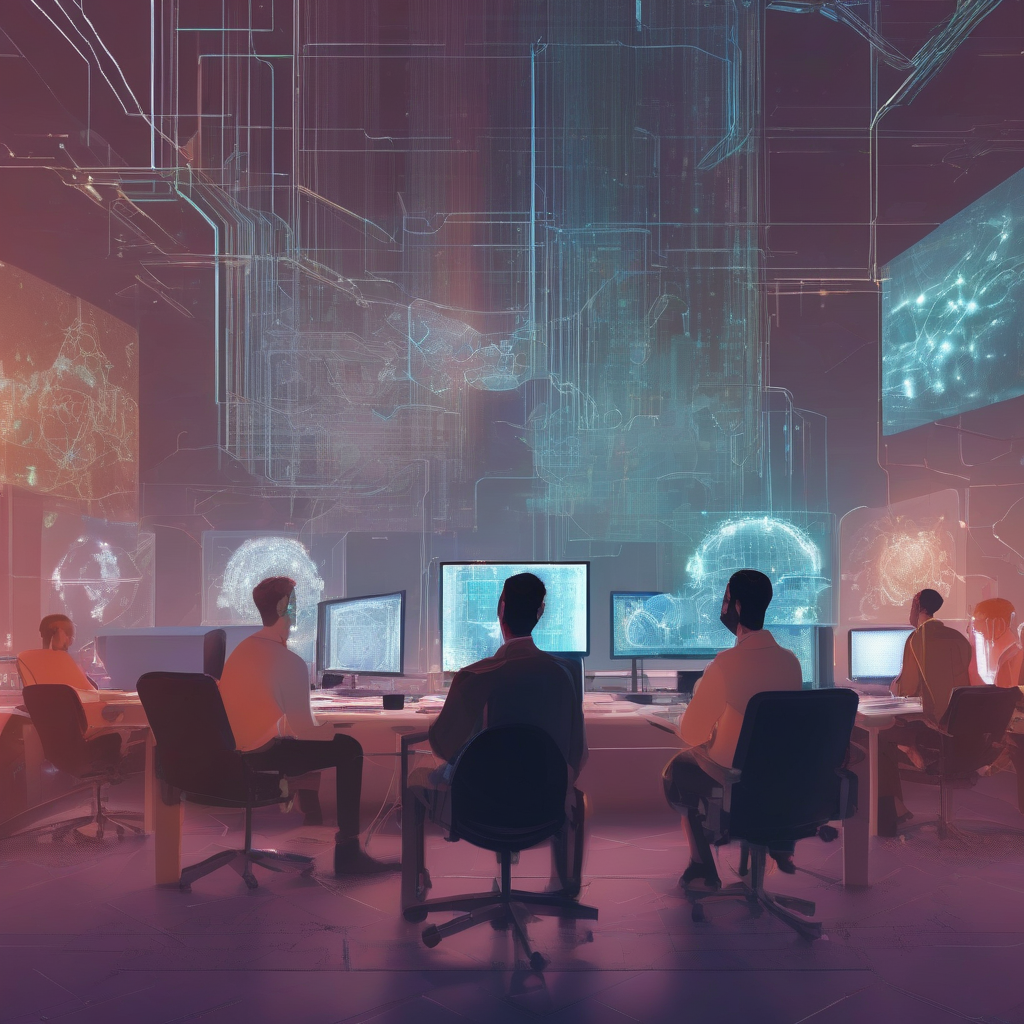

In [3]:
from IPython.display import display
from diffusers import DiffusionPipeline  # Generic pipeline loader
import torch

# Load SDXL Base 1.0 — the full high-quality image generation model
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True,   # use_safetensors=True → use the safer .safetensors file format (not pickle)
    variant="fp16"
).to(device)    # Move model to GPU

# Describe the image we want
prompt = "A class of data scientists learning AI engineering in a cinematic digital art style"

# Generate the image using 30 steps for full quality
image = pipe(prompt=prompt, num_inference_steps=30).images[0]

display(image)

In [4]:
# This clears ALL variables and GPU memory from Section 2A.
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

---
## Section 2B: SDXL Base + Refiner Pipeline — Two-Model Approach

**What is the Refiner?**
Stability AI released SDXL as a **two-model system**:
- **Base Model** → Does the heavy creative work — generates the overall composition, shapes, and structure
- **Refiner Model** → A specialist that takes the Base's output and sharpens fine details, textures, and faces

**The 80/20 Split:**
We split the total denoising steps between both models:
- Base handles the **first 80%** of steps (`denoising_end=0.8`)
- Refiner handles the **last 20%** of steps (`denoising_start=0.8`)

This produces noticeably sharper and more professional results than the Base alone.

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

model_index.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


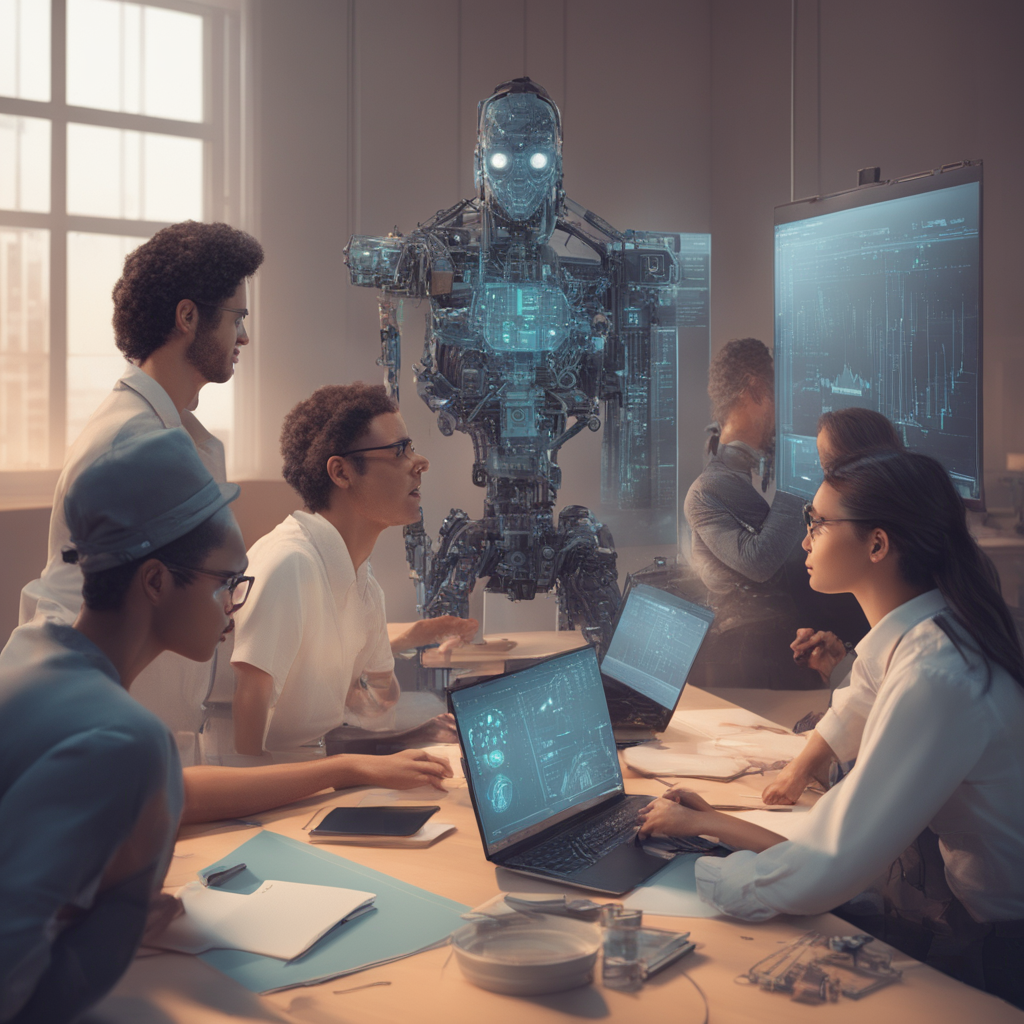

In [1]:
from diffusers import DiffusionPipeline
import torch

# Load Base Model
# Same as Section 2A — loads the main creative model
base = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)
base.to("cuda")

# Load Refiner Model
refiner = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    text_encoder_2=base.text_encoder_2,   # text_encoder_2=base.text_encoder_2 → REUSE the Base's text encoder (saves memory!)
    vae=base.vae,                         # vae=base.vae → REUSE the Base's image encoder/decoder (saves memory!)
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.to("cuda")

# Define Pipeline Parameters
n_steps = 40 # Total number of denoising steps across BOTH models

# The fraction of steps the BASE model handles (80%), The REFINER handles the remaining 20%
high_noise_frac = 0.8

prompt = "A class of data scientists learning AI engineering in a cinematic digital art style"

# Step 1: Run the Base Model
image = base(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,    # denoising_end=high_noise_frac → Base stops at 80% of steps
    output_type="latent",
).images
# output_type='latent' → Output raw latent tensors (not a full image yet) because the Refiner will continue processing these latents


# Step 2: Run the Refiner Model
image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,  # Start from where Base stopped
    image=image,                      # image=image → Pass the Base's latent output directly into the Refiner
).images[0]

display(image)

In [2]:
# This clears ALL variables and GPU memory from Section 2B.
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

---
## Section 3: SpeechT5 — Text-to-Speech (TTS)

**What is Text-to-Speech (TTS)?**
- TTS is an AI task where the model reads text and produces natural-sounding spoken audio — like a human voice reading it aloud.

**What is Microsoft SpeechT5?**
- SpeechT5 is a free, open-source TTS model by Microsoft on Hugging Face. What makes it special is **speaker voice cloning** — you can give it a 'speaker embedding' (a mathematical fingerprint of a real voice) and it will speak your text *in that person's voice style*.

**Why do we need `datasets`?**
- The speaker embeddings (voice fingerprints) are stored in a Hugging Face dataset called `cmu-arctic-xvectors`. We load one of the 7,000+ voices from this dataset to give the model a voice to speak in.

**Why upgrade `datasets` first?**
- A compatibility bug exists in older versions of the `datasets` library with certain audio features. Upgrading to `3.6.0` fixes this.

In [2]:
!pip install --upgrade datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.19
    Uninstalling multiprocess-0.70.19:
      Successfully uninstalled multiprocess-0.70.19
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5
ERROR: pip's dependency resolv

### Load the TTS Model and Generate Speech

**Step-by-step flow:**
1. Load `SpeechT5` TTS model via Hugging Face pipeline
2. Load a dataset of speaker voice embeddings (CMU-ARCTIC)
3. Pick one specific speaker voice (index `7306`) from that dataset
4. Convert your text to speech using that voice
5. Play the generated audio right inside the notebook

In [1]:
from transformers import pipeline       # Hugging Face pipeline to load TTS model
from datasets import load_dataset       # To load the speaker voice embeddings dataset
import soundfile as sf                  # For saving/reading audio files
import torch                            # For tensor operations on the embedding
from IPython.display import Audio       # To play audio inline in the notebook

# Load the TTS Model
synthesiser = pipeline(
    "text-to-speech",   # 'text-to-speech' is the Hugging Face task name
    "microsoft/speecht5_tts",   # 'microsoft/speecht5_tts' is the specific model we want
    device='cuda'
    )

# Load Speaker Voice Embeddings
embeddings_dataset = load_dataset(
    "matthijs/cmu-arctic-xvectors",   # This dataset contains xvectors (voice fingerprints) of real speakers
    split="validation",               # Each entry is a 512-dimensional vector that describes a unique voice
    trust_remote_code=True            # trust_remote_code=True is required for this dataset to execute its loading script
    )

# Select a Specific Speaker Voice
speaker_embedding = torch.tensor(
    embeddings_dataset[7306]["xvector"]   # Index 7306 picks one specific speaker from the dataset
    ).unsqueeze(0)    # unsqueeze(0) adds a batch dimension → shape becomes [1, 512] as required by the model

# The text we want the AI to speak out loud
prompt = """Hello and welcome to the world of Artificial Intelligence.
Today, we explore how machines can understand language, recognize patterns, and even generate human-like speech.
Text-to-Speech technology transforms written words into natural and expressive voices,
making information more accessible and interactive for everyone.
"""

# Generate Speech
speech = synthesiser(
    prompt,
    forward_params={"speaker_embeddings": speaker_embedding} # speaker_embeddings tells SpeechT5 which voice fingerprint to use
)

# Play the Audio Inline
Audio(
    speech["audio"],                # speech['audio'] → the raw audio waveform as a NumPy array
    rate=speech["sampling_rate"]    # speech['sampling_rate'] → tells Audio how many samples per second (e.g. 16000 Hz)
    )

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

[transformers] SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

spkrec-xvect.zip: reconstructing file:   0%|          |  0.00B / 17.9MB            

spkrec-xvect.zip: downloading bytes:           |  0.00B            

Generating validation split: 0 examples [00:00, ? examples/s]